In [ ]:
# Falta simular desfase, intensidad, consumo, detección de forma de onda...
# Es más para tener una idea de qué hacer y de ahí mejorar

In [ ]:
import math
import matplotlib.pyplot as plt
pi = math.pi

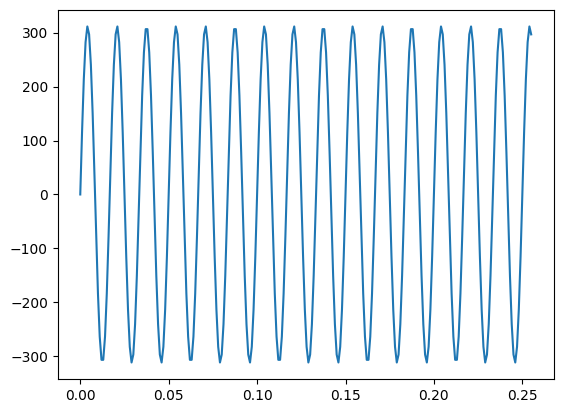

In [ ]:
# 256 muestras a 1000 samples/second (~ 1KB)
# Imitando las limitaciones de un arduino
sample = []
time = []
for i in range(256):
  sample.append(312 * math.sin(120*pi*i*0.001))
  time.append(i*0.001)

plt.plot(time, sample)
plt.show()

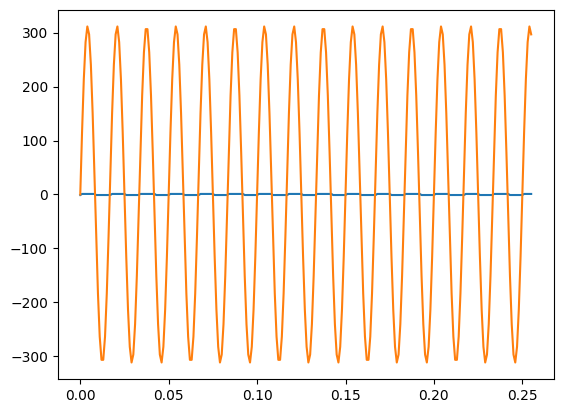

In [ ]:
# Schmidt trigger
# Siendo valores artificiales, los umbrales se pueden modificar para algo real
umbral_inferior = -50
umbral_superior = 50
output = []
state = False

for element in sample:
  if element > umbral_superior and not state:
    output.append(1)
    state = True
  elif element < umbral_inferior and state:
    output.append(-1)
    state = False
  elif state:
    output.append(1)
  elif not state:
    output.append(-1)


plt.plot(time, output)
plt.plot(time, sample)
plt.show()

In [ ]:
# Obtener duración aproximada de semiciclos
state = False
semicycle = []
on_state = 0
off_state = 0

for element in output:
  if element == 1 and not state:
    semicycle.append(off_state)
    off_state = 0
    on_state += 1
    state = True
  elif element == -1 and state:
    semicycle.append(on_state)
    on_state = 0
    off_state += 1
    state = False
  elif state:
    on_state += 1
  elif not state:
    off_state += 1

In [ ]:
# Calcular frecuencia en base a la duración promedio del ciclo
a = 0
for i in range(1, len(semicycle) - 1):
  a += semicycle[i]
a = 1 / ((2 * a / (len(semicycle) - 2)) * 0.001)
print(round(a, 1))

59.9


In [ ]:
# Calcular voltaje RMS
a = 0
for element in sample:
  a += element*element
a = math.sqrt(a / len(sample))
print(a)

220.89584014163754
